Я уже построила тепловую карту баблтишек, но нужно с этим что-то сделать. В этом разделе я буду анализировать заведения рядом с бабл ти кафе, которые могут помочь сделать выводы о том, где лучше сделать бабл ти кафе.

Я использую динамический парсинг, так с API ключами мы уже поработали и у них очень много ограничений.

Устанавливаем нужные библиотеки и браузер. Использую Playwright, так как он лучше работает с динамическими сайтами (то есть с Яндекс картами) и с ним проще установка браузера.

In [8]:
!pip install -q playwright
!playwright install --with-deps chromium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 MB 19.1 MB/s eta 0:00:00
Installing dependencies...
Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,021 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [95.6 kB]
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages

In [6]:
import pandas as pd

cafes = pd.read_csv('tea_places_df.csv')
cafes.head()

,id,name,full_name,address,lat,lon
0,70000001085801600,MojiTea bubble tea,NaN,"Ломоносовский проспект, 25 к5",55.692313,37.531752
1,70000001105863611,"Pims, магазин безалкогольных напитков",NaN,"Мичуринский проспект, 13а ст1",55.698676,37.513221
2,70000001077409967,"Davs Tea, безалкогольный бар",NaN,"площадь Джавахарлала Неру, 1",55.693451,37.534068
3,70000001095287732,"MosTea&Мифэнь, кофейня",NaN,"Вернадского проспект, 11",55.689362,37.530221
4,70000001105863722,Bobarista,NaN,"Мичуринский проспект, 13а ст1",55.698676,37.513221


In [9]:
import re
import time
import urllib.parse
import pandas as pd
from playwright.async_api import async_playwright

# будем искать рядом такие места
places = {
    'university': 'вуз',
    'college': 'колледж',
    'school': 'школа',
    'metro': 'станция метро',
    'mall': 'торговый центр',
    'office': 'бизнес центр'}


def make_url(place, lon, lat, zoom=16):
    place = urllib.parse.quote(place) # превращаем в безопасный для URL формат
    return f'https://yandex.ru/maps/213/moscow/search/{place}/?ll={lon}%2C{lat}&z={zoom}'


# вытаскиваем расстояние
def parse_distance(text):
    match = re.search(r'(\d+[,.]?\d*)\s*(м|км)', text)
    if not match:
        return None

    value = float(match.group(1).replace(',', '.'))
    unit = match.group(2)

    return round(value * 1000) if unit == 'км' else round(value)


async def scroll_results(page, steps=2):
    for _ in range(steps):
        await page.mouse.wheel(0, 1200)
        await page.wait_for_timeout(800)

# собираем инфу о найденных местах
async def collect_cards(page, max_cards=10):
    locator = page.locator("li[class*='search-snippet-view']")

    count = min(await locator.count(), max_cards)
    cards = []
    seen = set()

    for i in range(count):
        try:
            text = await locator.nth(i).inner_text(timeout=2000)
        except Exception:
            continue

        lines = [line.strip() for line in text.split("\n") if line.strip()]
        if not lines:
            continue

        name = lines[0]
        key = name.lower()

        if key in seen:
            continue

        seen.add(key)

        cards.append({
            "place_name": name,
            "place_text": " | ".join(lines),
            "distance": parse_distance(text),
        })

    return cards


async def scrape_yandex_nearby(cafes, max_cards=10):
    rows = []

    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=True) # загружаем браузер без видимого окна
        page = await browser.new_page(viewport={'width': 1400, 'height': 900}) # окно открываем

        for cafe in cafes.itertuples(index=False):
            for place_type, place in places.items():
                url = make_url(place, cafe.lon, cafe.lat)

                print(cafe.name, '->', place)

                try:
                    await page.goto(url, wait_until='domcontentloaded', timeout=60000)
                    await page.wait_for_timeout(5000)

                    await scroll_results(page)

                    cards = await collect_cards(page, max_cards=max_cards)

                    for card in cards:
                        rows.append({
                            'cafe_name': cafe.name,
                            'cafe_lon': cafe.lon,
                            'cafe_lat': cafe.lat,
                            'place_type': place_type,
                            'place_name': place,
                            **card})

                    await page.wait_for_timeout(1500)

                except Exception as error:
                    print('Ошибка:', cafe.name, place, error)

        await browser.close()

    return pd.DataFrame(rows)

Так как очень долго парсится данные, я разделила их на три ноутбука, чтобы ускорить процесс. Результаты из остальных данных я потом загружаю сюда

In [28]:
nearby_1 = await scrape_yandex_nearby(cafes.iloc[:37], max_cards=10)
nearby_1 = nearby_1.drop_duplicates(['cafe_name', 'place_type', 'place_name']).reset_index(drop=True)
nearby_1.head()

MojiTea bubble tea -> вуз
MojiTea bubble tea -> колледж
MojiTea bubble tea -> школа
MojiTea bubble tea -> станция метро
MojiTea bubble tea -> торговый центр
MojiTea bubble tea -> бизнес центр
Pims, магазин безалкогольных напитков -> вуз
Pims, магазин безалкогольных напитков -> колледж
Pims, магазин безалкогольных напитков -> школа
Pims, магазин безалкогольных напитков -> станция метро
Pims, магазин безалкогольных напитков -> торговый центр
Pims, магазин безалкогольных напитков -> бизнес центр
Davs Tea, безалкогольный бар -> вуз
Davs Tea, безалкогольный бар -> колледж
Davs Tea, безалкогольный бар -> школа
Davs Tea, безалкогольный бар -> станция метро
Davs Tea, безалкогольный бар -> торговый центр
Davs Tea, безалкогольный бар -> бизнес центр
MosTea&Мифэнь, кофейня -> вуз
MosTea&Мифэнь, кофейня -> колледж
MosTea&Мифэнь, кофейня -> школа
MosTea&Мифэнь, кофейня -> станция метро
MosTea&Мифэнь, кофейня -> торговый центр
MosTea&Мифэнь, кофейня -> бизнес центр
Bobarista -> вуз
Bobarista -> колл

ERROR:asyncio:Future exception was never retrieved
future: <Future finished exception=TargetClosedError('Target page, context or browser has been closed')>
playwright._impl._errors.TargetClosedError: Target page, context or browser has been closed


Nova Bubble Tea, бар безалкогольных напитков -> вуз
Nova Bubble Tea, бар безалкогольных напитков -> колледж
Nova Bubble Tea, бар безалкогольных напитков -> школа
Nova Bubble Tea, бар безалкогольных напитков -> станция метро
Nova Bubble Tea, бар безалкогольных напитков -> торговый центр
Nova Bubble Tea, бар безалкогольных напитков -> бизнес центр
Gege, чайный бар -> вуз
Gege, чайный бар -> колледж
Gege, чайный бар -> школа
Gege, чайный бар -> станция метро
Gege, чайный бар -> торговый центр
Gege, чайный бар -> бизнес центр


,cafe_name,cafe_lon,cafe_lat,place_type,place_name,place_text,distance
0,MojiTea bubble tea,37.531752,55.692313,university,Institut gosudarstvennogo administrirovaniya,Institut gosudarstvennogo administrirovaniya |...,NaN
1,MojiTea bubble tea,37.531752,55.692313,university,Lomonosov Moscow State University,Lomonosov Moscow State University | Photos | L...,NaN
2,MojiTea bubble tea,37.531752,55.692313,university,Moscow Business School,Moscow Business School | Photos | Moscow Busin...,NaN
3,MojiTea bubble tea,37.531752,55.692313,university,National University of Oil and Gas Gubkin Univ...,National University of Oil and Gas Gubkin Univ...,NaN
4,MojiTea bubble tea,37.531752,55.692313,university,Moscow City University,Moscow City University | Photos | Moscow City ...,NaN


In [35]:
nearby_1.to_csv('nearby_1.csv', index=False)
from google.colab import files
files.download('nearby_1.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,cafe_name,cafe_lon,cafe_lat,place_type,place_name,place_text,distance
0,MojiTea bubble tea,37.531752,55.692313,university,Institut gosudarstvennogo administrirovaniya,Institut gosudarstvennogo administrirovaniya |...,NaN
1,MojiTea bubble tea,37.531752,55.692313,university,Lomonosov Moscow State University,Lomonosov Moscow State University | Photos | L...,NaN
2,MojiTea bubble tea,37.531752,55.692313,university,Moscow Business School,Moscow Business School | Photos | Moscow Busin...,NaN
3,MojiTea bubble tea,37.531752,55.692313,university,National University of Oil and Gas Gubkin Univ...,National University of Oil and Gas Gubkin Univ...,NaN
4,MojiTea bubble tea,37.531752,55.692313,university,Moscow City University,Moscow City University | Photos | Moscow City ...,NaN


In [10]:
nearby_1 = pd.read_csv('nearby_1 (2).csv')

In [13]:
grouped_1 = (
    nearby_1
    .groupby(["cafe_name", "cafe_lon", "cafe_lat", "place_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index())

grouped_1.head()

place_type,cafe_name,cafe_lon,cafe_lat,college,mall,metro,office,school,university
0,"Chicha San Chen, бар тайваньского чая",37.537969,55.749070,5,6,6,5,5,0
1,D-Tea,37.539191,55.748729,5,6,6,5,5,7
2,"Dream tea, точка безалкогольных напитков",37.542187,55.749877,5,6,6,6,5,7
3,"Gege, чайный бар",37.562859,55.743426,5,6,6,6,5,7
4,"Hicha!, бар безалкогольных напитков",37.535905,55.746803,5,6,6,5,6,6


In [36]:
grouped_2 = pd.read_csv('grouped_2.csv')

In [37]:
grouped_3 = pd.read_csv('grouped_3.csv')

In [38]:
all_cafes = pd.concat([grouped_1, grouped_2, grouped_3],  ignore_index=True)
all_cafes.head(3)

,cafe_name,cafe_lon,cafe_lat,college,mall,metro,office,school,university
0,"Chicha San Chen, бар тайваньского чая",37.537969,55.749070,5,6,6,5,5,0
1,D-Tea,37.539191,55.748729,5,6,6,5,5,7
2,"Dream tea, точка безалкогольных напитков",37.542187,55.749877,5,6,6,6,5,7


Теперь пора делать выводы. Посмотрим распределение

In [39]:
import matplotlib.pyplot as plt

place_cols = ['college', 'mall', 'metro', 'office', 'school', 'university']

place_distribution = (
    all_cafes[place_cols]
    .sum()
    .sort_values(ascending=False)
    .rename_axis('place_type')
    .reset_index(name='count'))

place_distribution['share_%'] = (place_distribution['count'] / place_distribution['count'].sum() * 100).round(1)

place_distribution

,place_type,count,share_%
0,university,171,24.7
1,mall,146,21.1
2,office,115,16.6
3,college,95,13.7
4,school,87,12.6
5,metro,79,11.4


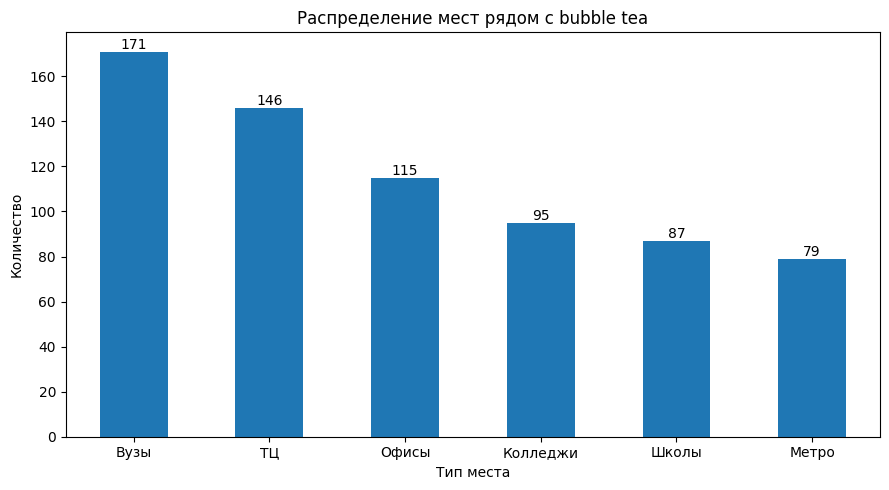

In [53]:
labels = {
    'university': 'Вузы',
    'mall': 'ТЦ',
    'school': 'Школы',
    'office': 'Офисы',
    'college': 'Колледжи',
    'metro': 'Метро'
}

plot_df = place_distribution.copy()
plot_df['place_type'] = plot_df['place_type'].map(labels)

ax = plot_df.plot(
    x='place_type',
    y='count',
    kind='bar',
    figsize=(9, 5),
    legend=False,
)

ax.set_title('Распределение мест рядом с bubble tea')
ax.set_xlabel('Тип места')
ax.set_ylabel('Количество')
ax.bar_label(ax.containers[0])

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
import pandas as pd
import folium
from folium.plugins import MarkerCluster

place_cols = ['college', 'mall', 'metro', 'office', 'school', 'university']

map_df = all_cafes.copy()
map_df['total_places'] = map_df[place_cols].sum(axis=1)

def demand_type(row):
    education = row['university'] + row['college'] + row['school']

    if education >= row['mall'] and education >= row['office']:
        return 'студенческий спрос'
    if row['mall'] >= education and row['mall'] >= row['office']:
        return 'торговый спрос'
    if row['office'] >= education and row['office'] >= row['mall']:
        return 'офисный спрос'
    return 'смешанный спрос'

map_df['demand_type'] = map_df.apply(demand_type, axis=1)

map_df[['cafe_name', 'demand_type', 'total_places']].head()

,cafe_name,demand_type,total_places
0,"Chicha San Chen, бар тайваньского чая",студенческий спрос,27
1,D-Tea,студенческий спрос,34
2,"Dream tea, точка безалкогольных напитков",студенческий спрос,35
3,"Gege, чайный бар",студенческий спрос,35
4,"Hicha!, бар безалкогольных напитков",студенческий спрос,34
